In [1]:
# 全局设置
import os
import datetime as dt
import warnings
warnings.filterwarnings(action='ignore')

import numpy as np
import pandas as pd
import matplotlib
matplotlib.rcParams['font.sans-serif'] = ['SimHei']
matplotlib.rcParams['axes.unicode_minus'] = False# 正确显示负号
from IPython.display import HTML

import QuantStudio.api as QS

In [2]:
# 参数设置
HDB = QS.Factor.HDF5DB(args={"MainDir": "../data/HDF5"}).connect()
RDB = QS.Risk.HDF5FRDB(args={"MainDir": "../data/Risk"}).connect()

StartDT, EndDT = dt.datetime(2025, 1, 1), dt.datetime(2025, 3, 31)# 数据起止时间
TestStartDT, TestEndDT = dt.datetime(2025, 1, 31), EndDT# 测试起止时间

FT = HDB.getTable("stock_cn_day_bar")
DTRuler = FT.getDateTime(start_dt=StartDT, end_dt=EndDT)
TestDTs = FT.getDateTime(start_dt=TestStartDT, end_dt=TestEndDT)
SectionIDs = IDs = FT.getID()

# 再平衡时点序列
BalanceDTs = QS.Tools.DateTime.getMonthLastDateTime(DTRuler)# 月末

2026-04-19 22:07:51,794 | QS | WARNING : 找不到配置文件: C:\Users\hst\QuantStudioConfig\HDF5FRDBConfig.json


2026-04-19 22:07:54,577 | QS | WARNING : 找不到配置文件: C:\Users\hst\QuantStudioConfig\FeatherFactorCacheConfig.json
2026-04-19 22:07:54,580 | QS | INFO : 开始初始化计算...
2026-04-19 22:07:54,582 | QS | INFO : 初始化计算完成, 耗时 0.0017996000096900389 秒
2026-04-19 22:07:54,583 | QS | INFO : 开始准备计算...
  0% (0 of 4) |                          | Elapsed Time: 0:00:00 ETA:  --:--:--
100% (4 of 4) |##########################| Elapsed Time: 0:00:00 Time:  0:00:00
2026-04-19 22:07:54,586 | QS | INFO : 准备计算完成, 耗时 0.002653099989402108 秒
2026-04-19 22:07:54,586 | QS | INFO : 开始正式计算...
2026-04-19 22:07:55,059 | QS | INFO : 正式计算完成, 耗时 0.4714685999933863 秒


,绝对表现,基准表现,相对表现
起始时点,2025-01-31,2025-01-31,2025-01-31
结束时点,2025-03-31,2025-03-31,2025-03-31
时点数,60,60,60
总收益率,110.12%,404.64%,-2702008.80%
年化收益率,9783.40%,2233233.73%,nan%
年化波动率,1029.96%,4251.35%,4393.64%
Sharpe比率,9.50,525.30,nan
收益风险比,9.50,525.30,nan
胜率,55.00%,50.00%,50.00%
最大回撤率,72.50%,98.33%,1113.97%

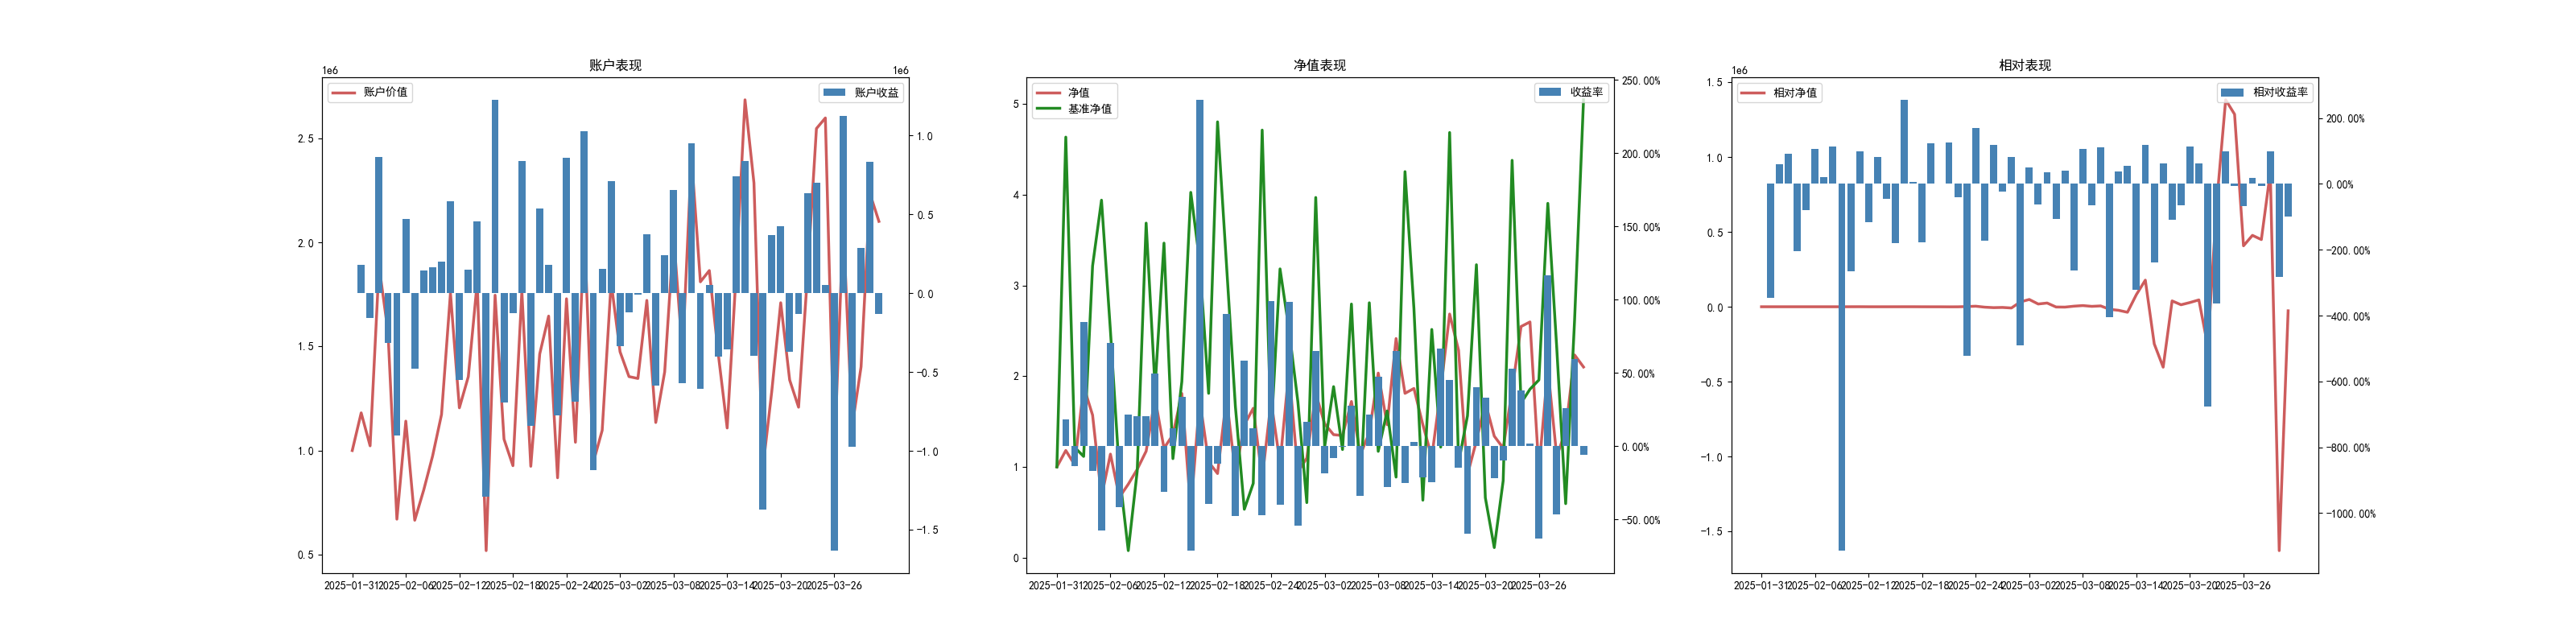

In [3]:
# 最小方差组合策略
class MakeMinVarStrategy(QS.BackTest.Strategy.MakeStrategy):
    """最小方差组合策略"""
    def genSignal(self, f, idt, x, last_price, cash, position_num, args):
        Mask, Cov = x[0].loc[idt].values, x[1].loc[idt].values
        IDs = x[0].columns.to_list()
        Objective = QS.PortfolioConstructor.MeanVarianceObjective(mask=Mask, cov=Cov, args={"ExpectedReturnCoef": 0, "RiskAversionCoef": 1})
        ConstraintList = [
            QS.PortfolioConstructor.WeightConstraint(mask=Mask, up_limit=1, down_limit=0),
            QS.PortfolioConstructor.BudgetConstraint(mask=Mask, args={"UpLimit": 1, "DownLimit": 1})
        ]

        # PC = QS.PortfolioConstructor.CVXPC(mask=Mask, objective=Objective, constraints=ConstraintList, args={"OptimOption": {"verbose": True}})
        PC = QS.PortfolioConstructor.CVXPC(mask=Mask, objective=Objective, constraints=ConstraintList, args={})
        Portfolio, Info = PC.solve()
        return pd.Series(np.where(np.abs(Portfolio) > 1e-8, Portfolio, 0), index=IDs).fillna(0)

FT = HDB.getTable("stock_cn_day_bar")
Price = FT.getFactor("close")

FT = HDB.getTable("stock_cn_status")
IfListed = FT.getFactor("if_listed")
Mask = (QS.Factor.fo.NotNull()(Price) & (IfListed == 1))

RT = RDB.getTable("demo_risk_table")

# 策略因子
makeMinVarStrategy = MakeMinVarStrategy(signal_type="目标权重", init_cash=1e6, start_dt=TestDTs[0], x_lookback=[0], x_section_ids=[None], signal_dts=BalanceDTs)
Strategy = makeMinVarStrategy(Mask, last_price=Price, extra_deps=[RT], extra_section_ids=[SectionIDs], extra_lookback=[0])

# 基准因子
FT = HDB.getTable("index_cn_day_bar")
BmkNV = FT.getFactor("close", args={"SectionIDs": ["000905.SH"]})

# 策略报告
StrategyReport = QS.BackTest.Strategy.AccountReport(account=Strategy, bmk_nv=BmkNV, args={"GenReport": True})

NodeList = [StrategyReport]
Report = QS.BackTest.BTReport(bt_node_list=NodeList)

with QS.Factor.FeatherFactorCache(args={"DTRuler": DTRuler, "CacheDir": "../data/Cache", "StartMode": "new"}) as Cache:
    with QS.Factor.FactorContext(DTRuler=DTRuler, SectionIDs=SectionIDs, DataCache=Cache) as Context:
        with QS.Core.Engine() as ExecEngine:
            Rslt = ExecEngine.run([Report], Context, fwd_data_list=[QS.Core.DTLocalContext(DTs=TestDTs)], init_data_list=[QS.Core.DTInitData(DTRange=(TestDTs[0], TestDTs[-1]))])

display(HTML(Rslt[0]["Report"]))